<a href="https://colab.research.google.com/github/DvLeu/Introduccion_NumpyPandas/blob/main/src/David_Leon_Salas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 02.- Proyecto en Python con Pandas
## Datos del alumno :
- Nombre : David León Salas
- Numero de control : 202680124
- Correo : 202680124@ucc.mx
- Fecha : 09 Octubre 2026

Datasets utilizados:
- Spotify (spotify_data clean.csv)
- Airbnb Nueva York (Airbnb_Open_Data.csv)
- Casas en Melbourne (melb_data.csv)

# 1. Carga de datos

In [1]:
# Instalar seaborn por si no esta en el entorno
%pip install seaborn -q

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Los csv estan en la carpeta Actividad01, si no existe (Colab) se leen de GitHub
if os.path.exists("Actividad01"):
    ruta = "Actividad01/"
    spotify_csv = "spotify_data clean.csv"
else:
    ruta = "https://raw.githubusercontent.com/DvLeu/Introduccion_NumpyPandas/main/src/Actividad01/"
    spotify_csv = "spotify_data%20clean.csv"

In [4]:
df_spotify = pd.read_csv(ruta + spotify_csv)
df_airbnb = pd.read_csv(ruta + "Airbnb_Open_Data.csv", low_memory=False)
df_melb = pd.read_csv(ruta + "melb_data.csv")

In [5]:
print(df_spotify.shape)
print(df_airbnb.shape)
print(df_melb.shape)

(8582, 15)
(102599, 26)
(13580, 21)


# 2. Detección de problemas

## Spotify

In [6]:
df_spotify.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [7]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

In [8]:
# Nulos

df_spotify.isnull().sum()

,0
track_id,0
track_name,0
track_number,0
track_popularity,0
explicit,0
artist_name,3
artist_popularity,0
artist_followers,0
artist_genres,3361
album_id,0


In [9]:
# Duplicados

df_spotify.duplicated().sum()

np.int64(0)

In [10]:
df_spotify.describe()

,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,13.789443,3.492805
std,6.052792,23.816076,19.645979,3.803180e+07,11.887131,1.057970
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


In [11]:
# La popularidad debe estar entre 0 y 100 y la duracion debe ser mayor a 0

print(df_spotify[(df_spotify["track_popularity"] < 0) | (df_spotify["track_popularity"] > 100)].shape[0])
print(df_spotify[df_spotify["track_duration_min"] <= 0].shape[0])

0
0


En Spotify no hay duplicados ni valores fuera de rango, pero faltan muchos géneros (artist_genres) y algunos nombres de artista. La fecha album_release_date viene como texto.

## Airbnb

In [12]:
df_airbnb.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [13]:
df_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [14]:
df_airbnb.isnull().sum()

,0
id,0
NAME,250
host id,0
host_identity_verified,289
host name,406
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532


In [15]:
df_airbnb.duplicated().sum()

np.int64(541)

In [16]:
df_airbnb.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [17]:
# price y service fee vienen con $

df_airbnb[["price", "service fee"]].head()

,price,service fee
0,$966,$193
1,$142,$28
2,$620,$124
3,$368,$74
4,$204,$41


In [18]:
df_airbnb["neighbourhood group"].value_counts()

,count
neighbourhood group,
Manhattan,43792
Brooklyn,41842
Queens,13267
Bronx,2712
Staten Island,955
brookln,1
manhatan,1


In [19]:
# Disponibilidad fuera de 0 a 365

df_airbnb[(df_airbnb["availability 365"] < 0) | (df_airbnb["availability 365"] > 365)].shape[0]

3214

In [20]:
# Noches minimas negativas o en 0

df_airbnb[df_airbnb["minimum nights"] <= 0].shape[0]

13

In [21]:
print(df_airbnb["country"].unique())
print(df_airbnb["country code"].unique())

['United States' nan]
['US' nan]


En Airbnb hay 541 filas duplicadas, price y service fee son texto, hay dos zonas mal escritas ("brookln" y "manhatan"), disponibilidades fuera de rango y noches mínimas negativas. country y country code solo tienen un valor y license está casi vacía.

## Melbourne

In [22]:
df_melb.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [23]:
df_melb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [24]:
df_melb.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [25]:
df_melb.duplicated().sum()

np.int64(0)

In [26]:
df_melb.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [27]:
# Casas con superficie construida en 0

df_melb[df_melb["BuildingArea"] == 0].shape[0]

17

In [28]:
# Años de construccion muy viejos o despues de la venta

anio_venta = pd.to_datetime(df_melb["Date"], dayfirst=True).dt.year
df_melb[(df_melb["YearBuilt"] < 1800) | (df_melb["YearBuilt"] > anio_venta)][["Date", "YearBuilt"]]

,Date,YearBuilt
441,3/12/2016,2017.0
1234,24/09/2016,2018.0
3489,23/04/2016,2017.0
4282,28/05/2016,2017.0
5153,17/09/2016,2017.0
7060,30/07/2016,2017.0
9968,24/06/2017,1196.0


En Melbourne no hay duplicados. BuildingArea y YearBuilt tienen muchos nulos, superficies en 0 y algunos años imposibles. Car y CouncilArea tienen pocos nulos y Landsize tiene valores muy grandes.

# 3. Limpieza

Estrategia:
- Eliminar duplicados
- Cambiar tipos de datos (fechas y precios)
- Los valores incorrectos se cambian a NaN
- Rellenar nulos con la mediana o con "Sin dato"
- Inferir valores cuando la columna solo tiene un valor
- Eliminar columnas casi vacías
- Recortar valores extremos

## Spotify

In [29]:
spotify = df_spotify.copy()
spotify = spotify.drop_duplicates()

In [30]:
spotify["album_release_date"] = pd.to_datetime(spotify["album_release_date"])
spotify["album_release_date"].dtype

dtype('<M8[ns]')

In [31]:
spotify["artist_name"] = spotify["artist_name"].fillna("Sin dato")
spotify["artist_genres"] = spotify["artist_genres"].fillna("Sin dato")
spotify.isnull().sum()

,0
track_id,0
track_name,0
track_number,0
track_popularity,0
explicit,0
artist_name,0
artist_popularity,0
artist_followers,0
artist_genres,0
album_id,0


## Airbnb

In [32]:
airbnb = df_airbnb.copy()

# nombres de columnas en minusculas y sin espacios
airbnb.columns = airbnb.columns.str.lower().str.replace(" ", "_")
airbnb = airbnb.drop_duplicates()
airbnb.shape

(102058, 26)

In [33]:
airbnb["neighbourhood_group"] = airbnb["neighbourhood_group"].replace({"brookln": "Brooklyn", "manhatan": "Manhattan"})
airbnb["neighbourhood_group"].value_counts()

,count
neighbourhood_group,
Manhattan,43558
Brooklyn,41631
Queens,13197
Bronx,2694
Staten Island,949


In [34]:
# Quitar $ y , para pasar a numero
# errors="coerce" --> lo que no se pueda convertir queda como NaN

airbnb["price"] = pd.to_numeric(airbnb["price"].str.replace("$", "").str.replace(",", ""), errors="coerce")
airbnb["service_fee"] = pd.to_numeric(airbnb["service_fee"].str.replace("$", "").str.replace(",", ""), errors="coerce")
airbnb[["price", "service_fee"]].describe()

,price,service_fee
count,101811.000000,101785.000000
mean,625.355580,125.039249
std,331.672649,66.325905
min,50.000000,10.000000
25%,340.000000,68.000000
50%,625.000000,125.000000
75%,913.000000,183.000000
max,1200.000000,240.000000


In [35]:
# valores fuera de rango a NaN

airbnb.loc[(airbnb["availability_365"] < 0) | (airbnb["availability_365"] > 365), "availability_365"] = np.nan
airbnb.loc[airbnb["minimum_nights"] <= 0, "minimum_nights"] = np.nan

In [36]:
airbnb["last_review"] = pd.to_datetime(airbnb["last_review"], format="%m/%d/%Y")

In [37]:
# Si no tiene reseñas entonces reviews_per_month es 0

airbnb.loc[(airbnb["number_of_reviews"] == 0) & (airbnb["reviews_per_month"].isnull()), "reviews_per_month"] = 0

In [38]:
# country y country_code solo tienen un valor, se rellenan con ese

airbnb["country"] = airbnb["country"].fillna("United States")
airbnb["country_code"] = airbnb["country_code"].fillna("US")

In [39]:
texto = ["name", "host_name", "neighbourhood_group", "neighbourhood", "host_identity_verified", "cancellation_policy", "house_rules"]
airbnb[texto] = airbnb[texto].fillna("Sin dato")

In [40]:
# license casi no tiene datos

airbnb["license"].isnull().sum()

np.int64(102056)

In [41]:
airbnb = airbnb.drop(columns=["license"])
airbnb.isnull().sum()

,0
id,0
name,0
host_id,0
host_identity_verified,0
host_name,0
neighbourhood_group,0
neighbourhood,0
lat,8
long,8
country,0


## Melbourne

In [42]:
melb = df_melb.copy()
melb.columns = melb.columns.str.lower()
melb["date"] = pd.to_datetime(melb["date"], dayfirst=True)

In [43]:
melb.loc[melb["buildingarea"] == 0, "buildingarea"] = np.nan
melb.loc[(melb["yearbuilt"] < 1800) | (melb["yearbuilt"] > melb["date"].dt.year), "yearbuilt"] = np.nan

In [44]:
# car se rellena con la mediana segun el tipo de casa

melb.groupby("type")["car"].median()

,car
type,
h,2.0
t,2.0
u,1.0


In [45]:
melb["car"] = melb["car"].fillna(melb.groupby("type")["car"].transform("median"))
melb["councilarea"] = melb["councilarea"].fillna("Sin dato")

In [46]:
# Recorte de landsize en el percentil 99

p99 = melb["landsize"].quantile(0.99)
melb["landsize_recortado"] = melb["landsize"].clip(upper=p99)
melb[["landsize", "landsize_recortado"]].describe()

,landsize,landsize_recortado
count,13580.000000,13580.000000
mean,558.416127,466.809932
std,3990.669241,432.673820
min,0.000000,0.000000
25%,177.000000,177.000000
50%,440.000000,440.000000
75%,651.000000,651.000000
max,433014.000000,2959.830000


In [47]:
melb.isnull().sum()

,0
suburb,0
address,0
rooms,0
type,0
price,0
method,0
sellerg,0
date,0
distance,0
postcode,0


Los nulos de buildingarea y yearbuilt se quedan porque son casi la mitad de los registros.

# 4. Nuevas columnas y memoria

In [48]:
# Spotify

spotify["anio"] = spotify["album_release_date"].dt.year
spotify["duracion_seg"] = spotify["track_duration_min"] * 60
spotify["popularidad"] = pd.cut(spotify["track_popularity"], bins=[-1, 33, 66, 100], labels=["Baja", "Media", "Alta"])
spotify["popularidad"].value_counts()

,count
popularidad,
Media,3956
Alta,2912
Baja,1714


In [49]:
spotify.groupby("album_type")[["track_popularity", "track_duration_min"]].mean()

,track_popularity,track_duration_min
album_type,,
album,55.655055,3.625668
compilation,40.512821,3.572249
single,46.356467,3.124024


In [50]:
# Airbnb

airbnb["precio_total"] = airbnb["price"] + airbnb["service_fee"]
airbnb["disponibilidad"] = airbnb["availability_365"] / 365
airbnb[["price", "service_fee", "precio_total", "disponibilidad"]].head()

,price,service_fee,precio_total,disponibilidad
0,966.0,193.0,1159.0,0.783562
1,142.0,28.0,170.0,0.624658
2,620.0,124.0,744.0,0.964384
3,368.0,74.0,442.0,0.882192
4,204.0,41.0,245.0,0.791781


In [51]:
airbnb.groupby("neighbourhood_group")["price"].median()

,price
neighbourhood_group,
Bronx,632.0
Brooklyn,626.0
Manhattan,621.0
Queens,628.0
Sin dato,661.0
Staten Island,628.0


In [52]:
# Melbourne

melb["antiguedad"] = melb["date"].dt.year - melb["yearbuilt"]
melb["precio_m2"] = melb["price"] / melb["buildingarea"]
melb[["price", "antiguedad", "precio_m2"]].head()

,price,antiguedad,precio_m2
0,1480000.0,NaN,NaN
1,1035000.0,116.0,13101.265823
2,1465000.0,117.0,9766.666667
3,850000.0,NaN,NaN
4,1600000.0,2.0,11267.605634


In [53]:
# Precios atipicos con el rango intercuartilico, solo se marcan

q1 = melb["price"].quantile(0.25)
q3 = melb["price"].quantile(0.75)
iqr = q3 - q1
melb["atipico"] = (melb["price"] < q1 - 1.5*iqr) | (melb["price"] > q3 + 1.5*iqr)
melb["atipico"].sum()

np.int64(612)

In [54]:
melb.groupby("type")[["price", "buildingarea"]].median()

,price,buildingarea
type,,
h,1080000.0,144.0
t,846750.0,130.0
u,560000.0,75.0


In [55]:
# np.where() --> casas a 10 km o menos del centro

melb["cerca_centro"] = np.where(melb["distance"] <= 10, "Si", "No")
melb.groupby("cerca_centro")["price"].median()

,price
cerca_centro,
No,835000.0
Si,980000.0


**Consultas**

In [56]:
# Las 10 canciones mas populares

spotify.sort_values(by="track_popularity", ascending=False)[["track_name", "artist_name", "album_type", "track_popularity"]].head(10)

,track_name,artist_name,album_type,track_popularity
457,Golden,HUNTR/X,album,99
88,Opalite,Taylor Swift,album,97
101,Elizabeth Taylor,Taylor Swift,album,95
337,Man I Need,Olivia Dean,single,95
103,Father Figure,Taylor Swift,album,94
1134,BIRDS OF A FEATHER,Billie Eilish,album,94
450,Soda Pop,Saja Boys,album,94
460,Your Idol,Saja Boys,album,93
93,Actually Romantic,Taylor Swift,album,93
97,Wood,Taylor Swift,album,93


In [57]:
# Anuncios de Manhattan con calificacion 5 y mas reseñas

airbnb[(airbnb["neighbourhood_group"] == "Manhattan") & (airbnb["review_rate_number"] == 5)][["name", "room_type", "price", "number_of_reviews"]].sort_values(by="number_of_reviews", ascending=False).head(10)

,name,room_type,price,number_of_reviews
53823,City Queen,Hotel room,451.0,583.0
49915,"Private Room in Spacious Quiet Apt., Elevator ...",Private room,288.0,567.0
63880,Penthouse Studio East 50s Terrace,Private room,167.0,490.0
50838,Amazing East Village XL ground floor Apartment!,Entire home/apt,1178.0,451.0
2164,TriBeCa 2500 Sq Ft w/ Priv Elevator,Entire home/apt,70.0,447.0
70340,TriBeCa 2500 Sq Ft w/ Priv Elevator,Entire home/apt,70.0,447.0
62949,Location is Everything. And Quiet Too!,Private room,233.0,446.0
53144,S+ Location Midtown Studio Apt,Entire home/apt,1034.0,418.0
67969,Prime location near Central Park !!,Private room,1042.0,403.0
53212,☆ STUDIO East Village ☆ Own bath! ☆ Sleeps 5,Entire home/apt,1166.0,386.0


In [58]:
# Precio mediano por region

melb.groupby("regionname")["price"].median().sort_values(ascending=False)

,price
regionname,
Southern Metropolitan,1250000.0
Eastern Metropolitan,1010000.0
South-Eastern Metropolitan,850000.0
Northern Metropolitan,806250.0
Western Metropolitan,793000.0
Eastern Victoria,670000.0
Northern Victoria,540000.0
Western Victoria,400000.0


**Memoria**

Las columnas de texto con pocos valores se cambian a category y algunos números a int8 / float32.

In [59]:
print(spotify.memory_usage(deep=True).sum() / 1024**2)
print(airbnb.memory_usage(deep=True).sum() / 1024**2)
print(melb.memory_usage(deep=True).sum() / 1024**2)

4.344879150390625
91.24833679199219
7.677462577819824


In [60]:
spotify["album_type"] = spotify["album_type"].astype("category")
spotify["track_popularity"] = spotify["track_popularity"].astype("int8")
spotify["artist_popularity"] = spotify["artist_popularity"].astype("int8")

airbnb["neighbourhood_group"] = airbnb["neighbourhood_group"].astype("category")
airbnb["room_type"] = airbnb["room_type"].astype("category")
airbnb["cancellation_policy"] = airbnb["cancellation_policy"].astype("category")
airbnb["host_identity_verified"] = airbnb["host_identity_verified"].astype("category")
airbnb["country"] = airbnb["country"].astype("category")
airbnb["country_code"] = airbnb["country_code"].astype("category")

melb["type"] = melb["type"].astype("category")
melb["method"] = melb["method"].astype("category")
melb["regionname"] = melb["regionname"].astype("category")
melb["councilarea"] = melb["councilarea"].astype("category")
melb["rooms"] = melb["rooms"].astype("int8")
melb["car"] = melb["car"].astype("int8")
melb["distance"] = melb["distance"].astype("float32")

In [61]:
print(spotify.memory_usage(deep=True).sum() / 1024**2)
print(airbnb.memory_usage(deep=True).sum() / 1024**2)
print(melb.memory_usage(deep=True).sum() / 1024**2)

3.791769027709961
58.01052474975586
4.546490669250488


# 5. Visualizaciones

In [62]:
plt.rcParams["figure.figsize"] = (9, 6)

## Spotify

In [63]:
spotify[["track_popularity", "artist_popularity", "artist_followers", "track_duration_min"]].corr()

,track_popularity,artist_popularity,artist_followers,track_duration_min
track_popularity,1.000000,0.466903,0.232019,0.105560
artist_popularity,0.466903,1.000000,0.635579,0.207769
artist_followers,0.232019,0.635579,1.000000,0.172140
track_duration_min,0.105560,0.207769,0.172140,1.000000


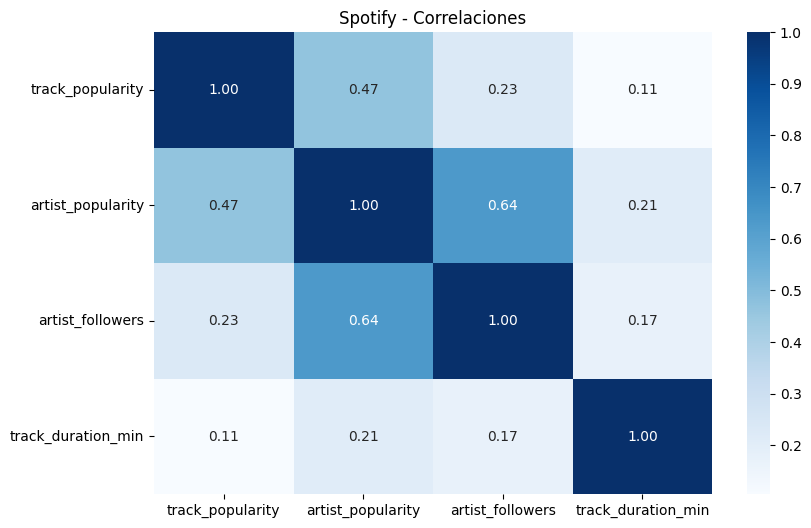

In [64]:
sns.heatmap(spotify[["track_popularity", "artist_popularity", "artist_followers", "track_duration_min"]].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Spotify - Correlaciones")
plt.show()

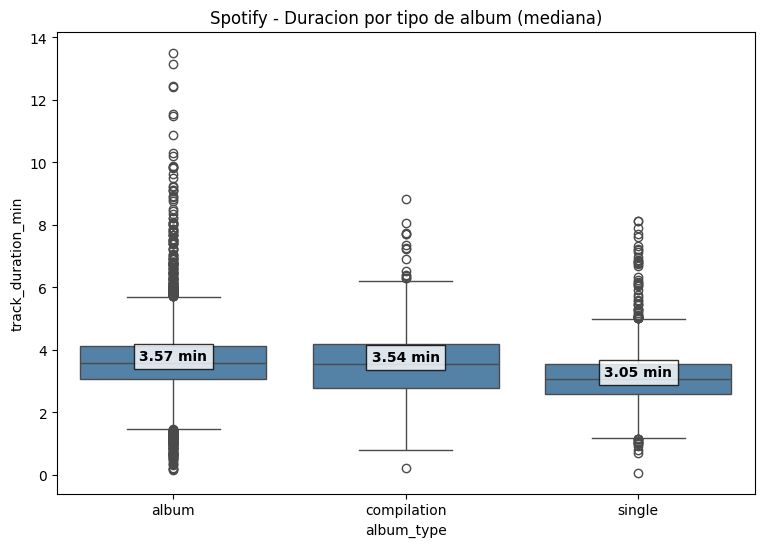

In [65]:
sns.boxplot(data=spotify, x="album_type", y="track_duration_min", color="steelblue")

# mediana de cada caja
medianas = spotify.groupby("album_type", observed=True)["track_duration_min"].median()
for i, m in enumerate(medianas):
    plt.text(i, m, str(round(m, 2)) + " min", ha="center", va="bottom", fontweight="bold", bbox=dict(facecolor="white", alpha=0.8))

plt.title("Spotify - Duracion por tipo de album (mediana)")
plt.show()

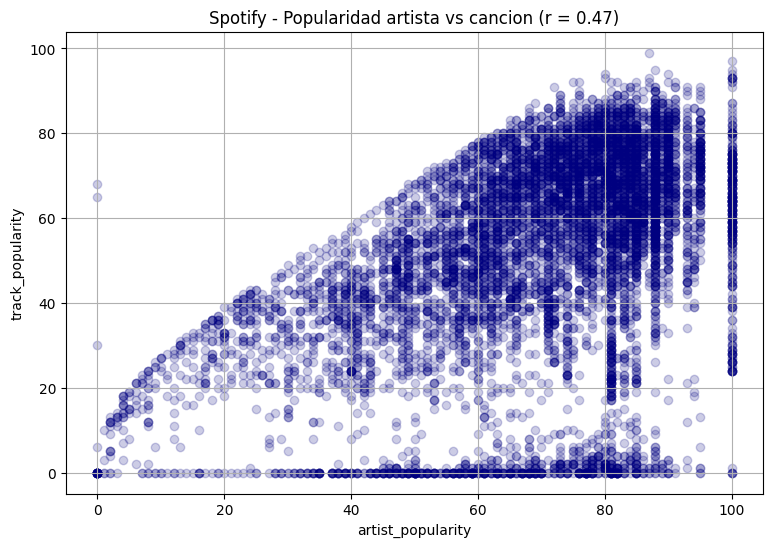

In [66]:
r = spotify["artist_popularity"].corr(spotify["track_popularity"])

plt.scatter(spotify["artist_popularity"], spotify["track_popularity"], color="navy", alpha=0.2)
plt.title("Spotify - Popularidad artista vs cancion (r = " + str(round(r, 2)) + ")")
plt.xlabel("artist_popularity")
plt.ylabel("track_popularity")
plt.grid(True)
plt.show()

## Airbnb

In [67]:
airbnb[["price", "service_fee", "minimum_nights", "number_of_reviews", "review_rate_number", "availability_365"]].corr()

,price,service_fee,minimum_nights,number_of_reviews,review_rate_number,availability_365
price,1.000000,0.999991,-0.002717,0.005085,-0.004647,-0.001601
service_fee,0.999991,1.000000,-0.002899,0.004978,-0.004461,-0.001866
minimum_nights,-0.002717,-0.002899,1.000000,-0.050536,-0.002718,0.070362
number_of_reviews,0.005085,0.004978,-0.050536,1.000000,-0.018279,0.099625
review_rate_number,-0.004647,-0.004461,-0.002718,-0.018279,1.000000,0.003370
availability_365,-0.001601,-0.001866,0.070362,0.099625,0.003370,1.000000


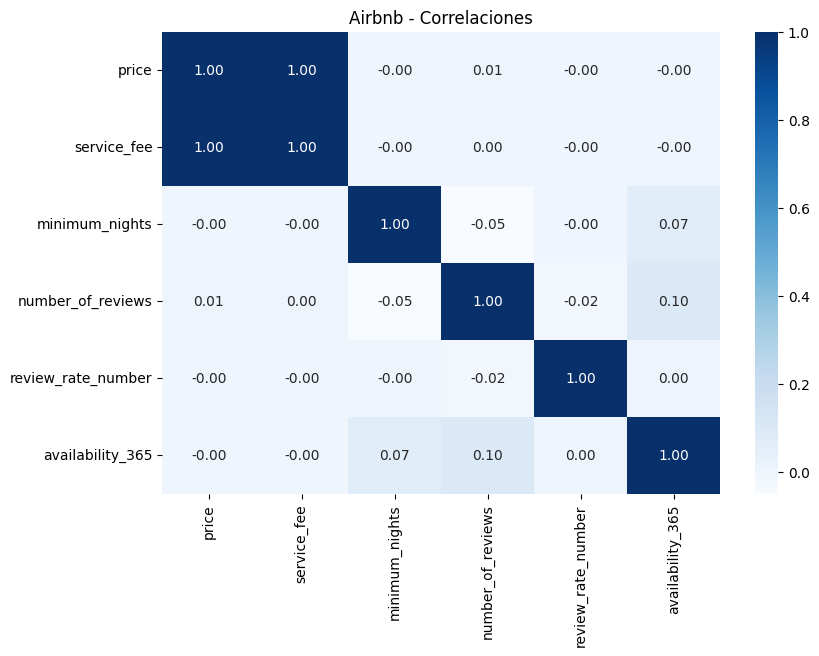

In [68]:
sns.heatmap(airbnb[["price", "service_fee", "minimum_nights", "number_of_reviews", "review_rate_number", "availability_365"]].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Airbnb - Correlaciones")
plt.show()

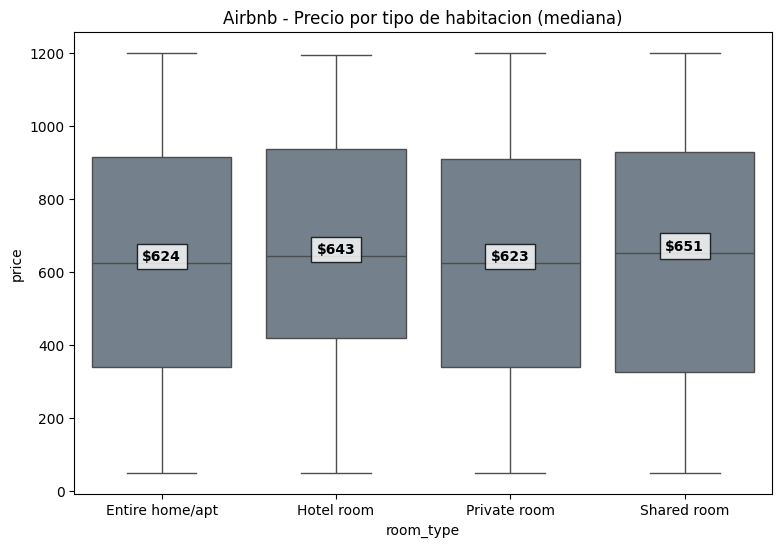

In [69]:
sns.boxplot(data=airbnb, x="room_type", y="price", color="slategray")

medianas = airbnb.groupby("room_type", observed=True)["price"].median()
for i, m in enumerate(medianas):
    plt.text(i, m, "$" + str(int(m)), ha="center", va="bottom", fontweight="bold", bbox=dict(facecolor="white", alpha=0.8))

plt.title("Airbnb - Precio por tipo de habitacion (mediana)")
plt.show()

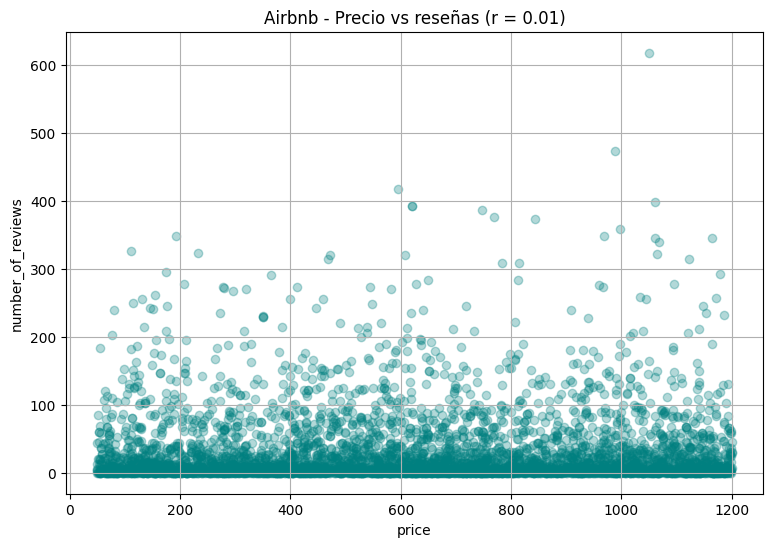

In [70]:
# muestra de 5000 porque son muchos puntos, la r se calcula con todos los datos

r = airbnb["price"].corr(airbnb["number_of_reviews"])
muestra = airbnb.sample(5000, random_state=1)

plt.scatter(muestra["price"], muestra["number_of_reviews"], color="teal", alpha=0.3)
plt.title("Airbnb - Precio vs reseñas (r = " + str(round(r, 2)) + ")")
plt.xlabel("price")
plt.ylabel("number_of_reviews")
plt.grid(True)
plt.show()

## Melbourne

In [71]:
melb[["price", "rooms", "distance", "bathroom", "car", "landsize_recortado", "buildingarea", "antiguedad"]].corr()

,price,rooms,distance,bathroom,car,landsize_recortado,buildingarea,antiguedad
price,1.000000,0.496634,-0.162522,0.467038,0.239250,0.184360,0.091576,0.331948
rooms,0.496634,1.000000,0.294203,0.592934,0.407239,0.261697,0.124682,0.068311
distance,-0.162522,0.294203,1.000000,0.127155,0.260728,0.223824,0.099802,-0.251712
bathroom,0.467038,0.592934,0.127155,1.000000,0.321127,0.150598,0.112263,-0.153190
car,0.239250,0.407239,0.260728,0.321127,1.000000,0.241707,0.096192,-0.109937
landsize_recortado,0.184360,0.261697,0.223824,0.150598,0.241707,1.000000,0.112718,-0.001151
buildingarea,0.091576,0.124682,0.099802,0.112263,0.096192,0.112718,1.000000,-0.019751
antiguedad,0.331948,0.068311,-0.251712,-0.153190,-0.109937,-0.001151,-0.019751,1.000000


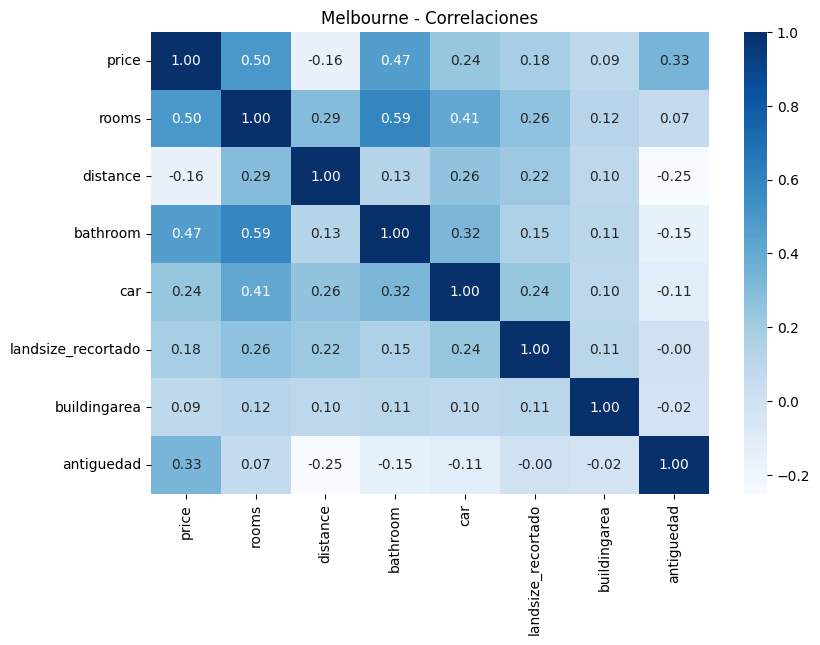

In [72]:
sns.heatmap(melb[["price", "rooms", "distance", "bathroom", "car", "landsize_recortado", "buildingarea", "antiguedad"]].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Melbourne - Correlaciones")
plt.show()

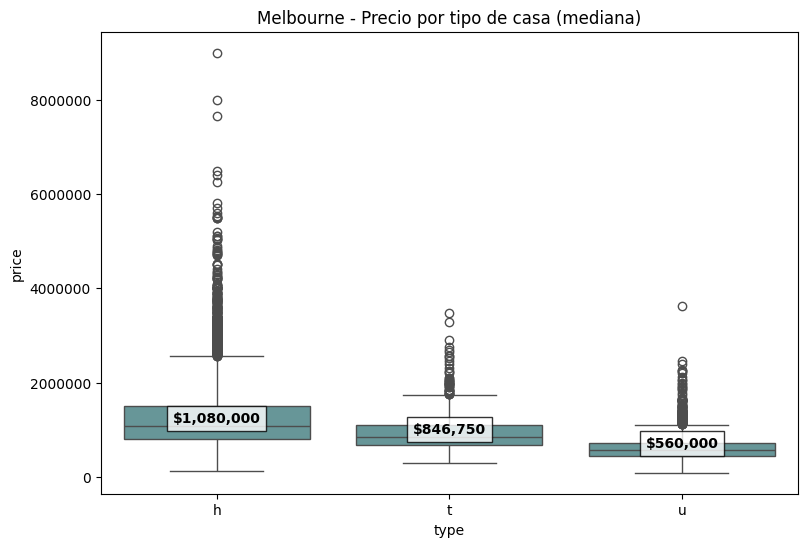

In [73]:
sns.boxplot(data=melb, x="type", y="price", color="cadetblue")

medianas = melb.groupby("type", observed=True)["price"].median()
for i, m in enumerate(medianas):
    plt.text(i, m, "$" + format(int(m), ","), ha="center", va="bottom", fontweight="bold", bbox=dict(facecolor="white", alpha=0.8))

plt.ticklabel_format(style="plain", axis="y")
plt.title("Melbourne - Precio por tipo de casa (mediana)")
plt.show()

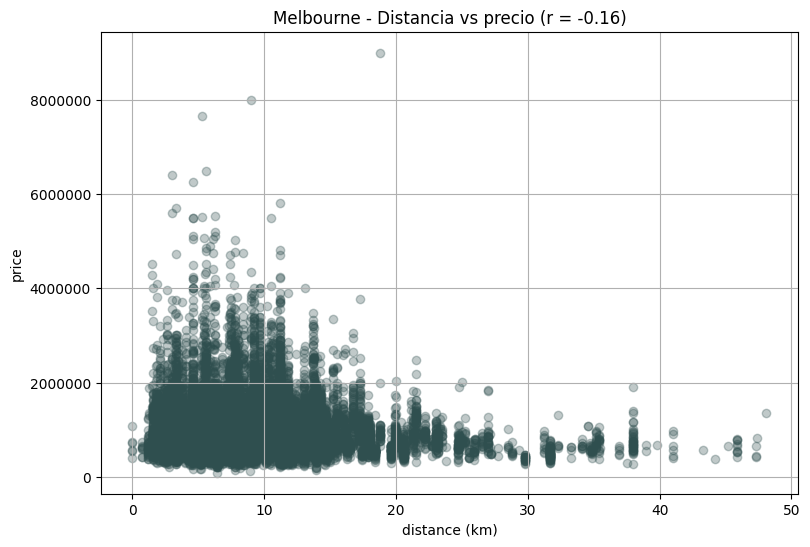

In [74]:
r = melb["distance"].corr(melb["price"])

plt.scatter(melb["distance"], melb["price"], color="darkslategray", alpha=0.3)
plt.ticklabel_format(style="plain", axis="y")
plt.title("Melbourne - Distancia vs precio (r = " + str(round(r, 2)) + ")")
plt.xlabel("distance (km)")
plt.ylabel("price")
plt.grid(True)
plt.show()

## Conclusiones

- Spotify: la popularidad de la canción se relaciona con la popularidad del artista (0.47). Los singles duran menos que las canciones de álbum. Casi el 40% de las canciones no tiene género.
- Airbnb: price y service_fee tienen correlación de 1 porque la tarifa es más o menos el 20% del precio. El precio casi no cambia entre zonas ni tipos de habitación y no se relaciona con las reseñas.
- Melbourne: el precio sube con los cuartos (0.50) y los baños (0.47) y baja un poco con la distancia (-0.16). Las casas (h) son las más caras y los departamentos (u) los más baratos. Las casas a 10 km o menos del centro tienen un precio mediano mayor ($980,000 contra $835,000).

# 6. Guardar datasets limpios

In [75]:
os.makedirs("datos_limpios", exist_ok=True)

spotify.to_csv("datos_limpios/spotify_limpio.csv", index=False)
airbnb.to_csv("datos_limpios/airbnb_limpio.csv", index=False)
melb.to_csv("datos_limpios/melbourne_limpio.csv", index=False)

In [76]:
# Resumen antes y despues de la limpieza

resumen = pd.DataFrame({
    "Dataset": ["Spotify", "Airbnb", "Melbourne"],
    "Filas antes": [df_spotify.shape[0], df_airbnb.shape[0], df_melb.shape[0]],
    "Filas despues": [spotify.shape[0], airbnb.shape[0], melb.shape[0]],
    "Columnas antes": [df_spotify.shape[1], df_airbnb.shape[1], df_melb.shape[1]],
    "Columnas despues": [spotify.shape[1], airbnb.shape[1], melb.shape[1]],
    "Duplicados antes": [df_spotify.duplicated().sum(), df_airbnb.duplicated().sum(), df_melb.duplicated().sum()],
    "Duplicados despues": [spotify.duplicated().sum(), airbnb.duplicated().sum(), melb.duplicated().sum()],
    "Archivo": ["spotify_limpio.csv", "airbnb_limpio.csv", "melbourne_limpio.csv"]
})
resumen

,Dataset,Filas antes,Filas despues,Columnas antes,Columnas despues,Duplicados antes,Duplicados despues,Archivo
0,Spotify,8582,8582,15,18,0,0,spotify_limpio.csv
1,Airbnb,102599,102058,26,27,541,0,airbnb_limpio.csv
2,Melbourne,13580,13580,21,26,0,0,melbourne_limpio.csv
